**Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use California Housing Dataset for Linear Regression and Auto MPG Dataset (for vehicle fuel efficiency prediction) for Polynomial Regression.**

In [15]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

Linear Regression

---


In [34]:
# Load + split
data = fetch_california_housing()
X_cal, y_cal = data.data, data.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cal, y_cal, test_size = 0.2, random_state = 42
)

In [35]:
# Train + predict
model_cal = LinearRegression().fit(Xc_train, yc_train)
y_pred_cal = model_cal.predict(Xc_test)

In [36]:
# Evaluate
mse_cal = mean_squared_error(yc_test, y_pred_cal)
print(f"MSE (California Housing): {mse_cal:.2f}")

MSE (California Housing): 0.56


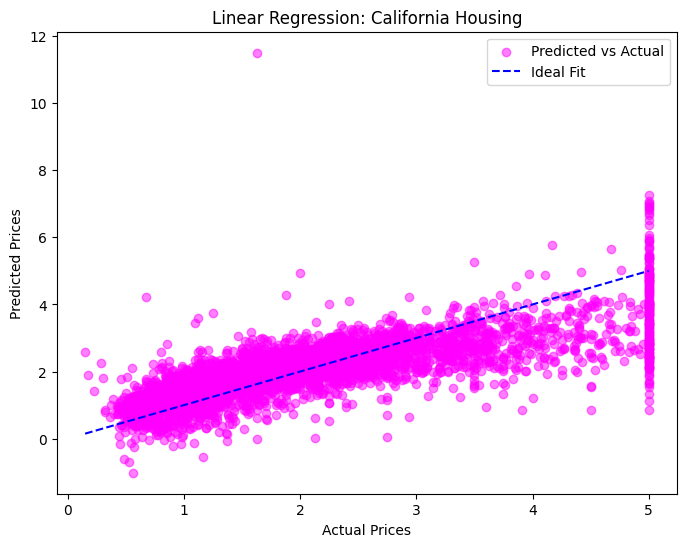

In [37]:
# Plot
plt.figure(figsize = (8, 6))
plt.scatter(yc_test, y_pred_cal, color = "magenta", alpha = 0.5, label = "Predicted vs Actual")
plt.plot([yc_test.min(), yc_test.max()],
         [yc_test.min(), yc_test.max()],
         color = "blue",
         linestyle = "--", label = "Ideal Fit")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: California Housing")
plt.legend()
plt.show()

Polynomial Regression

---



In [38]:
# Load data
df = pd.read_csv("{path_to_your_file}")
X_auto = df[['displacement', 'weight', 'acceleration']]
y_auto = df['mpg']

In [39]:
# Split
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_auto, y_auto, test_size = 0.2, random_state = 42
)

In [40]:
# Scale + polynomial features
scaler = StandardScaler()
Xa_train_s = scaler.fit_transform(Xa_train)
Xa_test_s = scaler.transform(Xa_test)

poly = PolynomialFeatures(degree = 2)
Xa_train_p = poly.fit_transform(Xa_train_s)
Xa_test_p = poly.transform(Xa_test_s)

In [41]:
# Train + predict
model_auto = LinearRegression().fit(Xa_train_p, ya_train)
y_pred_auto = model_auto.predict(Xa_test_p)

In [42]:
# Evaluate
mse_auto = mean_squared_error(ya_test, y_pred_auto)
print(f"MSE (Auto-MPG Polynomial): {mse_auto:.2f}")

MSE (Auto-MPG Polynomial): 11.99


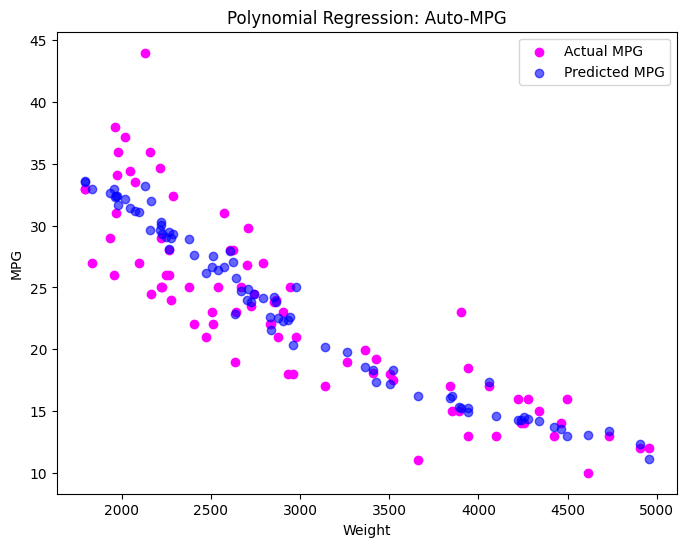

In [43]:
# Plot
plt.figure(figsize = (8, 6))
plt.scatter(Xa_test['weight'], ya_test, color = "magenta", label = "Actual MPG")
plt.scatter(Xa_test['weight'], y_pred_auto, color = "blue", alpha = 0.6, label = "Predicted MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Polynomial Regression: Auto-MPG")
plt.legend()
plt.show()